# MD-CLARA tutorial: multidomain patent trajectories by city

This notebook walks through **multidomain CLARA** (`md_clara`) on an empirical application: **city-level patent intensity sequences** in three technology domains:

1. **Computing**
2. **Medicine**
3. **Environmental technology**

Each city is one sequence. Time is organized in **3-year windows** from 1980–1982 to 2013–2014. States are **global quintiles** of patent activity (`No patents`, `Very Low`, …, `Very High`).

You will learn how to:

- Load and **align** three domain datasets on `city_id`
- Build one `SequenceData` object per domain
- Run **MD-CLARA** (scalable CLARA for multidomain analysis)
- Read quality, clustering, medoids, and stability outputs
- Plot diagnostic figures

For background on multidomain strategies (IDCD, CAT, DAT), see the [main multidomain tutorial](main_tutorial.ipynb) and Ritschard et al. (2023).

**Compare all three strategies (IDCD, CAT, DAT)** on the same data: [md_clara_patent_cities_strategies.ipynb](md_clara_patent_cities_strategies.ipynb).

**Individual-level example (pairfam activity + family):** [md_clara_pairfam_tutorial.ipynb](md_clara_pairfam_tutorial.ipynb) · [md_clara_pairfam_strategies.ipynb](md_clara_pairfam_strategies.ipynb).

## 1. Setup

Install Sequenzo if needed (`pip install sequenzo` or your local editable install).  
Adjust `DATA_ROOT` if your patent data live elsewhere.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sequenzo import SequenceData
from sequenzo.multidomain.clara import (
    md_clara,
    plot_md_clara_quality,
    plot_md_clara_stability,
)
from sequenzo.visualization import plot_sequence_index

%matplotlib inline

# Root folder of the global-south patent sequence project (edit if needed)
DATA_ROOT = Path(
    "/Users/lei/Documents/Sequenzo_all_folders/global-south-sequential-patent-data"
    "/data/02_analysis_ready/sequence/domain"
)

PATHS = {
    "computing": DATA_ROOT
    / "computing/y3/computing_3years_global_quintiles_patent_sequence_data_by_city.csv",
    "medicine": DATA_ROOT
    / "medicine/y3/medicine_3years_global_quintiles_patent_sequence_data_by_city.csv",
    "environmental": DATA_ROOT
    / "environmental_technology/y3"
    / "environmental_technology_3years_global_quintiles_patent_sequence_data_by_city.csv",
}

for name, path in PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {name} data: {path}")

## 2. Load the three domain datasets

Each CSV has metadata columns (`city_id`, `city`, `country_code`, …) and **12 time columns** with quintile labels.

In [2]:
dfs = {name: pd.read_csv(path) for name, path in PATHS.items()}

meta_cols = ["city_id", "city", "country_code", "country_name", "continent"]
time_cols = [c for c in dfs["computing"].columns if c[0].isdigit() and "-" in c]

for name, df in dfs.items():
    print(f"{name:14s}  rows={len(df):5d}  time points={len(time_cols)}")

dfs["computing"].head()

computing       rows= 1455  time points=12
medicine        rows= 1485  time points=12
environmental   rows= 1508  time points=12


,city_id,city,country_code,country_name,continent,1980-1982,1983-1985,1986-1988,1989-1991,1992-1994,1995-1997,1998-2000,2001-2003,2004-2006,2007-2009,2010-2012,2013-2014
0,9GQ4+4M_IN,9GQ4+4M,IN,India,Asia,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,Very Low,No patents
1,Abu Road_IN,Abu Road,IN,India,Asia,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,Very Low
2,Acapulco de Juárez_MX,Acapulco de Juárez,MX,Mexico,Latin America,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,Low,No patents
3,Adana_TR,Adana,TR,Turkey,Unknown,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,High
4,Addanki_IN,Addanki,IN,India,Asia,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,No patents,Low,No patents,No patents


## 3. Align cities across domains

Multidomain analysis requires the **same units** in the **same order** in every domain. We keep cities present in all three files and sort by `city_id`.

In [3]:
common_ids = set(dfs["computing"]["city_id"])
for name in ("medicine", "environmental"):
    common_ids &= set(dfs[name]["city_id"])

print(f"Cities in all three domains: {len(common_ids)}")

aligned = {}
for name, df in dfs.items():
    sub = df[df["city_id"].isin(common_ids)].sort_values("city_id").reset_index(drop=True)
    aligned[name] = sub
    assert list(sub["city_id"]) == list(aligned["computing"]["city_id"])

# City metadata (one row per city)
city_meta = aligned["computing"][meta_cols].copy()
city_meta.head()

Cities in all three domains: 633


,city_id,city,country_code,country_name,continent
0,Agra_IN,Agra,IN,India,Asia
1,Aguascalientes_MX,Aguascalientes,MX,Mexico,Latin America
2,Ahmadabad_IN,Ahmadabad,IN,India,Asia
3,Ahmadnagar_IN,Ahmadnagar,IN,India,Asia
4,Ajmer_IN,Ajmer,IN,India,Asia


## 4. Define states and build `SequenceData` per domain

`SequenceData` is the core Sequenzo object. We use the same state alphabet in each domain so quintiles are comparable.

In [4]:
STATES = ["No patents", "Very Low", "Low", "Medium", "High", "Very High"]
LABELS = STATES

domains = []
domain_names = ["computing", "medicine", "environmental"]

for name in domain_names:
    seq = SequenceData(
        aligned[name],
        time=time_cols,
        id_col="city_id",
        states=STATES,
        labels=LABELS,
    )
    domains.append(seq)
    print(seq)

[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 633
[>] Number of time points: 12
[>] Min/Max sequence length: 12 / 12
[>] States: ['No patents', 'Very Low', 'Low', 'Medium', 'High', 'Very High']
[>] Labels: ['No patents', 'Very Low', 'Low', 'Medium', 'High', 'Very High']
[>] Void: '%' (not in states (inactive); not observed in data) — out-of-window padding; SAMM/seqsamm drops subsequences containing void
[>] Weights: Not provided
SequenceData(633 sequences, States: ['No patents', 'Very Low', 'Low', 'Medium', 'High', 'Very High'])
[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 633
[>] Number of time points: 12
[>] Min/Max sequence length: 12 / 12
[>] States: ['No paten

### Quick look: example city trajectories (one domain)

Below we plot the first few cities in the **computing** domain. Repeat for other domains if you like.

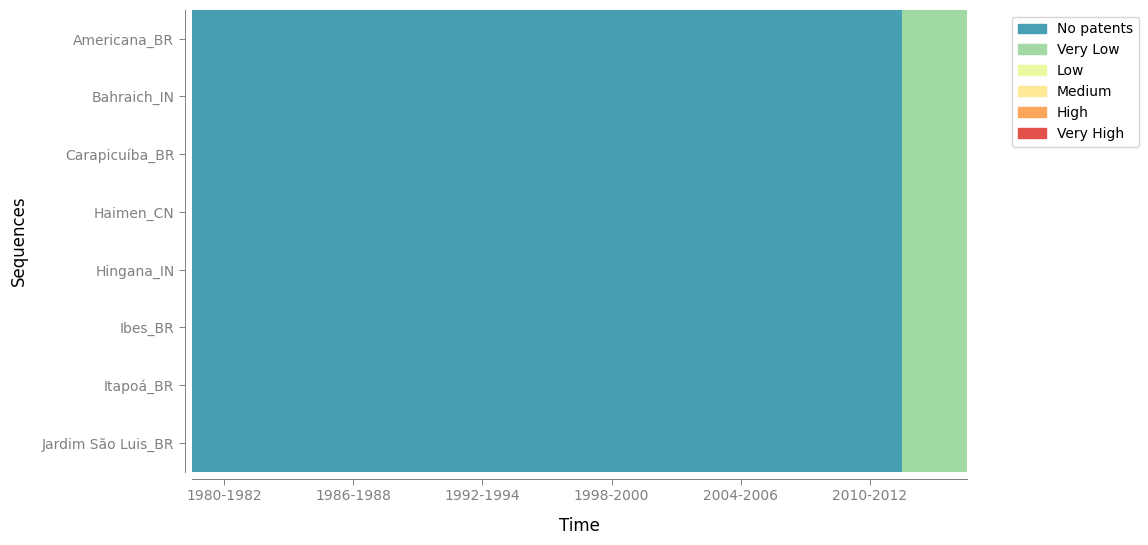

<Figure size 640x480 with 0 Axes>

In [5]:
plot_sequence_index(
    domains[0],
    show_sequence_ids=True,
    sequence_selection="first_n",
    n_sequences=8,
)
plt.suptitle("Computing domain — sample cities", y=1.02)
plt.show()

## 5. What does `md_clara` do?

**CLARA** (Clustering LARge Applications) finds cluster typologies by repeatedly sampling subsets, estimating medoids, and assigning all sequences—without building a full `N × N` distance matrix in memory.

**MD-CLARA** extends this to several domains via a dissimilarity **strategy**:

| Strategy | Idea |
|----------|------|
| `idcd` | Distances on **expanded** multidomain states (domain1+domain2+domain3) |
| `cat` | Concatenation-style multidomain substitution costs |
| `dat` | Aggregate (e.g. sum) of domain-specific distances |

This tutorial uses **`idcd`**, which is the default and works well when domains are associated.

Important parameters:

- `R`: number of CLARA random subsamples
- `sample_size`: size of each subsample (must be ≥ `max(kvals)`)
- `kvals`: cluster sizes to try (e.g. 2–6)
- `distance_params`: passed to optimal matching (`OM` here)
- `stability=True`: bootstrap-style stability summaries

For a first run we use moderate settings so the notebook finishes in a few minutes on a laptop. Increase `R` and `sample_size` for publication-quality results.

In [6]:
MD_CLARA_KWARGS = dict(
    strategy="idcd",
    distance_params={
        "method": "OM",
        "sm": "CONSTANT",
        "indel": 1,
        "norm": "none",
    },
    R=30,
    sample_size=200,
    kvals=[2, 3, 4, 5, 6],
    criteria=("distance",),
    stability=True,
    random_state=42,
    n_jobs=-1,
    verbose=True,
)

result = md_clara(domains, **MD_CLARA_KWARGS)
result

[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 387
[>] Number of time points: 12
[>] Min/Max sequence length: 12 / 12
[>] States: ['No patents+No patents+No patents', 'Very High+Very High+Very High', 'No patents+No patents+Very Low', 'No patents+Very Low+No patents', 'No patents+No patents+Very High', 'No patents+No patents+High', 'Very Low+No patents+No patents', 'No patents+No patents+Medium', 'Very High+Very High+High', 'No patents+No patents+Low', 'No patents+Low+No patents', 'No patents+High+No patents', 'High+No patents+No patents', 'Low+No patents+No patents', 'High+Very High+Very High', 'No patents+Medium+No patents', 'No patents+Very Low+Very Low', 'No patents+Very High+Very High', 'No patents+High+Very High', 'No patents+High+Very Low', 'Medium+No patents+No patents', 'High+High+Medium', 'Very High+Very High+Medium',

MDClaraResult(strategy='idcd', method='crisp', kvals=[2, 3, 4, 5, 6], best_by_k={2: {'medoids': array([ 14, 436]), 'medoids_agg': array([ 14, 291]), 'clustering': array([1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 2., 2., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 2., 1., 2., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 1., 2., 1., 1., 1.,
       1., 1., 1., 1., 2., 2., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       2., 1., 1., 1., 1., 2., 2., 2., 1., 2., 1., 1., 2., 1., 1., 1., 1.,
       2., 2., 1., 1., 1., 1., 2., 2., 2., 1., 1., 1., 2., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 2., 2., 2., 1., 1., 2.,
       2., 1., 2., 1., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       2., 2., 1., 1., 1., 1., 2., 2., 1., 1., 1., 1., 1., 2., 1., 1., 1.,
       2., 1., 1., 1., 2., 2., 1., 1., 2., 2., 1., 1., 1., 2., 1., 2., 1.,
       1., 1

## 6. Explore the `MDClaraResult` object

The result bundles:

- `result.stats` — cluster quality by `k`
- `result.clustering` — city labels for each `k` (`Cluster 2`, …)
- `result.medoids` — medoid row indices per `k`
- `result.stability` — ARI/Jaccard stability (if requested)
- `result.settings` — run configuration

In [7]:
print("Strategy:", result.strategy)
print("Settings:", result.settings)

result.stats

Strategy: idcd
Settings: {'strategy': 'idcd', 'method': 'crisp', 'kvals': [2, 3, 4, 5, 6], 'distance_params': {'method': 'OM', 'sm': 'CONSTANT', 'indel': 1, 'norm': 'none'}, 'R': 30, 'sample_size': 200, 'criteria': ['distance'], 'stability': True}


,k,avg_dist,pbm,db,xb,ams,ari08,jc08,best_iter,criterion,R,sample_size,strategy
0,2,10.432859,0.744181,1.329736,0.579603,0.426580,5.0,23.0,4.0,distance,30,200,idcd
1,3,9.633491,0.579476,1.390926,0.688107,0.372471,5.0,5.0,0.0,distance,30,200,idcd
2,4,9.232227,0.354905,1.645774,1.154028,0.250595,3.0,3.0,11.0,distance,30,200,idcd
3,5,9.026856,0.237592,1.755323,1.128357,0.256391,5.0,5.0,27.0,distance,30,200,idcd
4,6,8.751975,0.175522,1.804902,1.093997,0.255527,1.0,1.0,17.0,distance,30,200,idcd


In [8]:
# Cluster assignments (all k in wide format)
result.clustering.head(10)

,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
Agra_IN,1.0,2.0,1.0,2.0,6.0
Aguascalientes_MX,1.0,2.0,1.0,2.0,6.0
Ahmadabad_IN,2.0,1.0,1.0,5.0,3.0
Ahmadnagar_IN,1.0,2.0,3.0,1.0,1.0
Ajmer_IN,1.0,2.0,3.0,1.0,1.0
Alfajayucan_MX,1.0,2.0,1.0,1.0,1.0
Aligarh_IN,1.0,2.0,1.0,1.0,1.0
Alipur_IN,1.0,2.0,1.0,5.0,1.0
Allahabad_IN,1.0,1.0,1.0,2.0,3.0
Alto de Pinheiros_BR,1.0,2.0,1.0,2.0,6.0


### Choose a cluster count `k`

Inspect `avg_dist` (average distance to medoids; **lower is better**) and stability columns. Here we pick `k=4` as an example—you should justify `k` from substantive and diagnostic criteria.

In [9]:
K_CHOSEN = 4

labels = result.best_clustering(K_CHOSEN)
cluster_df = city_meta.copy()
cluster_df[f"cluster_k{K_CHOSEN}"] = labels

cluster_df[f"cluster_k{K_CHOSEN}"].value_counts().sort_index()

cluster_k4
1.0    284
2.0     67
3.0    186
4.0     96
Name: count, dtype: int64

In [10]:
cluster_df.sort_values(f"cluster_k{K_CHOSEN}").head(12)

,city_id,city,country_code,country_name,continent,cluster_k4
593,Xinghua_CN,Xinghua,CN,China,Asia,1.0
587,Wujiang_CN,Wujiang,CN,China,Asia,1.0
586,Wuhu_CN,Wuhu,CN,China,Asia,1.0
607,Yichun_CN,Yichun,CN,China,Asia,1.0
603,Yangzhou_CN,Yangzhou,CN,China,Asia,1.0
601,Ya'an_CN,Ya'an,CN,China,Asia,1.0
38,Baoshan_CN,Baoshan,CN,China,Asia,1.0
36,Banki_IN,Banki,IN,India,Asia,1.0
282,Kurnool_IN,Kurnool,IN,India,Asia,1.0
281,Kunshan_CN,Kunshan,CN,China,Asia,1.0


## 7. Diagnostic plots

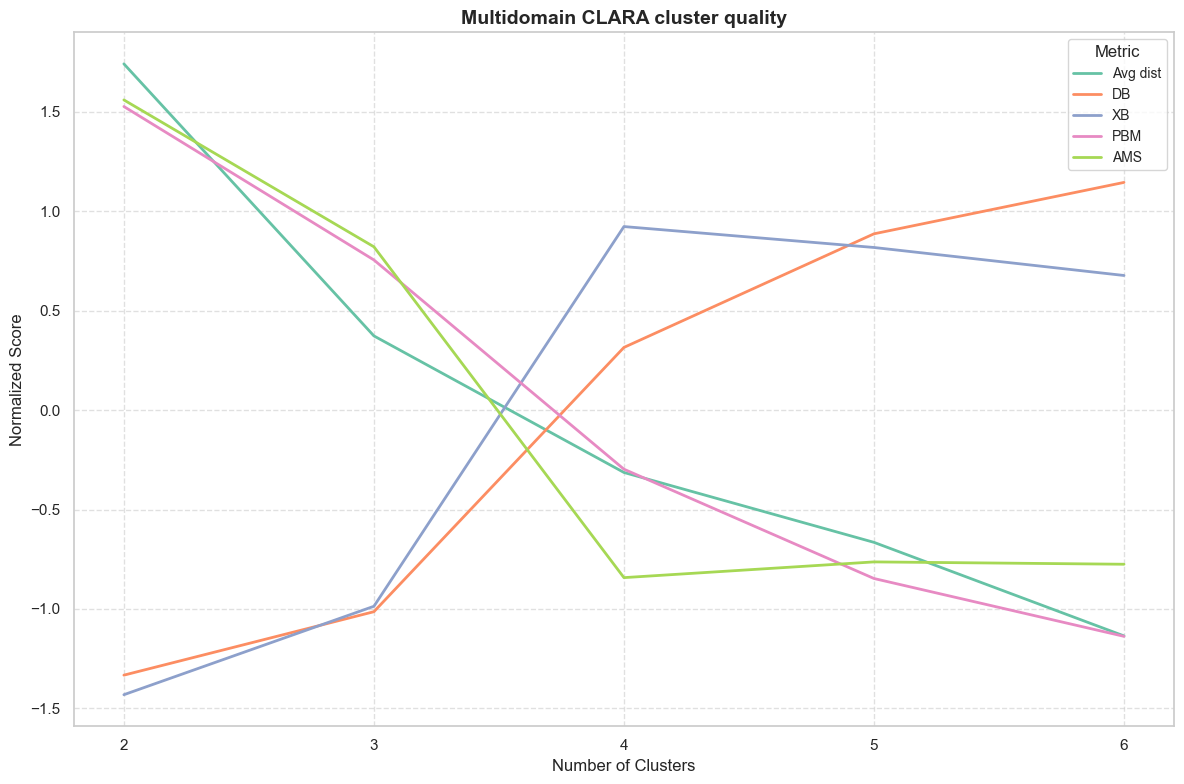

In [11]:
plot_md_clara_quality(result)
plt.show()

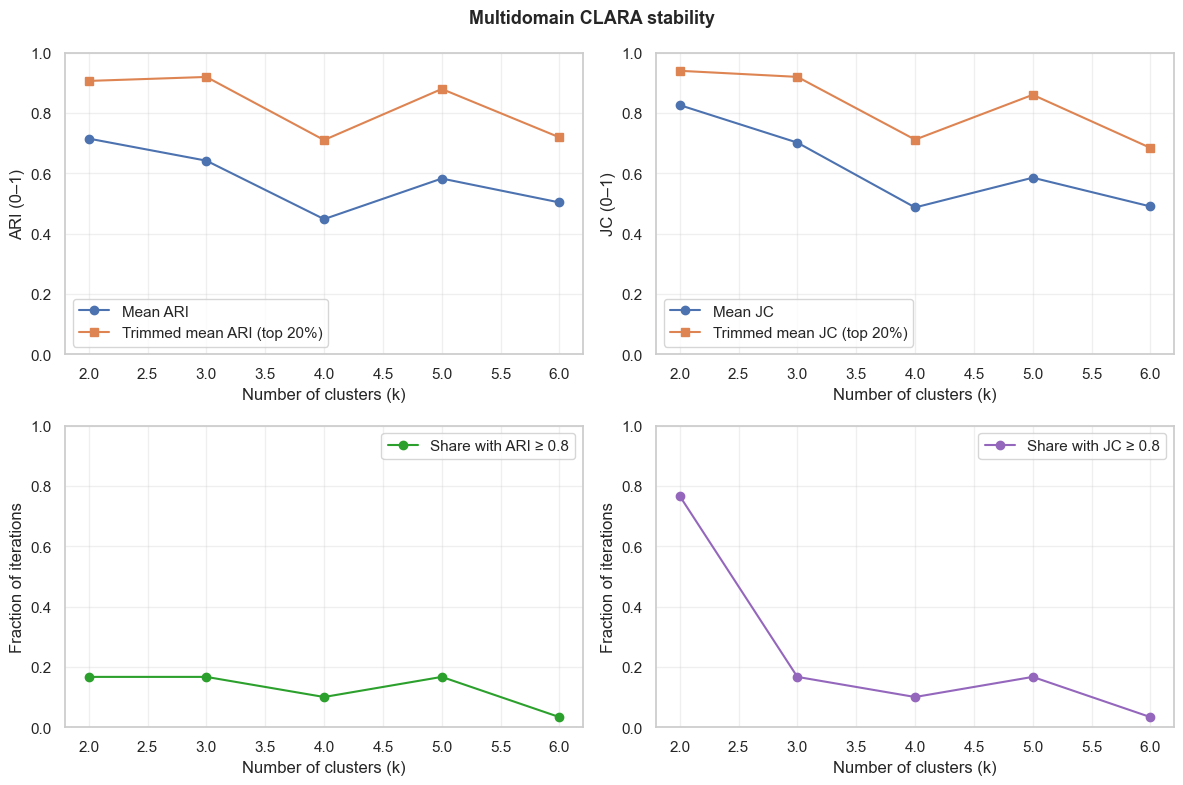

In [12]:
plot_md_clara_stability(result)
plt.show()

## 8. Export results (optional)

Join cluster labels with metadata for maps, regression, or descriptive tables.

In [ ]:
export = cluster_df.join(result.clustering)
out_path = Path("md_clara_patent_cities_clusters.csv")
export.to_csv(out_path, index=False)
print(f"Saved: {out_path.resolve()}")

## 9. Next steps

- **Run IDCD, CAT, and DAT on the same data:** [md_clara_patent_cities_strategies.ipynb](md_clara_patent_cities_strategies.ipynb)
- Increase `R` (e.g. 100) and `sample_size` (e.g. 500+) for more stable medoids.
- Use `plot_md_cluster_by_domain` to visualize how clusters differ across domains.
- Relate `cluster_df` to country/continent or other covariates for interpretation.

Documentation: `docs/multidomain/md-clara.md` in the Sequenzo repository.